<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**

ChicStyle is a growing fashion retailer that receives a large spike in customer reviews during festive seasons and holiday sales. These reviews contain critical signals about customer experience, including fit, size, fabric quality, color accuracy, delivery issues, and overall satisfaction. If this feedback is not analyzed quickly, the business may miss urgent complaints, fail to respond to dissatisfied customers in time, and risk lower trust, fewer repeat purchases, and damage to brand reputation.

This problem is important because simple sentiment analysis is not enough for retail decision-making. A review may be positive about one aspect of a product and negative about another, such as praising style but criticizing fit or quality. Generative AI is useful here because it can understand the full context of a review, identify whether the feedback is about a product or service issue, summarize the concern, and translate that feedback into actionalbe business insights.

### **Objective**

The objective is to build a Generative AI pipeline that can automatically process customer reviews and convert them into structured, actionable insights for the retail business. The system should:

* identify the feedback category,
* detect sentiment,
* summarize the review,
* create a personalized customer response,
* extract a retail insight,
* predict whether a customer would recommend a product, and
* compare prompt-engineering strategies to determine the approach that produces the most reliable and useful outputs.

### **Dataset Used for the Notebook**
The dataset used in this notebook is a women’s clothing e-commerce review dataset containing customer-written feedback along with related product and customer metadata. Important columns include `Clothing.ID`, `Age`, `Title`, `Review.Text`, `Rating`, `Recommended.IND`, `Positive.Feedback.Count`, `Division.Name`, `Department.Name`, and `Class.Name`.

The most important feature for this project is `Review.Text`, since it contains the unstructured customer feedback that the Generative AI model must analyze. The `Rating` and `Recommended.IND` columns help validate customer sentiment and recommendation behavior, while `Division.Name`, `Department.Name`, and `Class.Name` provide product-level business context for analysis. Since there is no separate service-feedback column, the model must infer from the review text whether the feedback refers to product issues such as fit or quality, or service-related issues such as delivery or support.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
# Install the required libraries for the project
!pip -q install pandas matplotlib seaborn plotly wordcloud scikit-learn openai tqdm

In [ ]:
# Import the required libraries for the project

# Core utilities
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Data handling
import pandas as pd
from google.colab import userdata

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# Machine learning metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer

# Progress bar
from tqdm import tqdm

# OpenAI client
import openai

# Set global plot style
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

### **Data Loading**
### Loading and Understanding the Data


In [ ]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the dataset
df = pd.read_csv('/content/drive/MyDrive/MIT Data Science/Capstone/Dataset - Real-Time Retail Feedback Intelligence.csv', sep=';', index_col=0)
display(df)

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a great price! it's very easy to slip on and has a very flattering cut and color combo.,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stretchy, shiny material. cut is flattering and drapes nicely. i only found one button to close front... looked awkward. nice long sleeves.\r\nnot for me ...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see through. this never would have worked for me. i'm glad i was able to try it on in the store and didn't order it online. with different fabric, it would have...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties and we","I bought this dress for a wedding i have this summer, and it's so cute. unfortunately the fit isn't perfect. the medium fits my waist perfectly, but was way too long and too big in the bust and sh...",3,1,2,General,Dresses,Dresses


### **Data Overview**

In [ ]:
# Get a summary of the dataset to check data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended.IND          23486 non-null  int64 
 6   Positive.Feedback.Count  23486 non-null  int64 
 7   Division.Name            23472 non-null  object
 8   Department.Name          23472 non-null  object
 9   Class.Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


### **Sanity checks**

In [ ]:
# Check the total number of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64


### **Data Cleaning and Preprocessing**

**Think about it:** The `Review.Text` column is the most critical feature for the Generative AI model. What should be done with rows where this text is missing?  

Rows where this text is missing should be removed from the modeling dataset because the LLM cannot infer sentiment, category, summary, recommendation intent, or customer response without the actual review content. Other missing fields, such as `Title`, can be retained because they are optional metadata and are not required for the core prompt.

In [ ]:
# Drop rows with no review text
df = df.dropna(subset=["Review.Text"]).copy()
df["Review.Text"] = df["Review.Text"].astype(str).str.strip()
df = df[df["Review.Text"] != ""].copy()

print("\nMissing Values after cleaning:")
print(df.isnull().sum())


Missing Values after cleaning:
Clothing.ID                   0
Age                           0
Title                      2966
Review.Text                   0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                13
Department.Name              13
Class.Name                   13
dtype: int64


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

In [ ]:
# Summary statistics for numerical columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,22641.0,919.33,202.27,1.0,861.0,936.0,1078.0,1205.0
Age,22641.0,43.28,12.33,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.18,1.12,1.0,4.0,5.0,5.0,5.0
Recommended.IND,22641.0,0.82,0.39,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,22641.0,2.63,5.79,0.0,0.0,1.0,3.0,122.0


In [ ]:
# Distribution plot of customer age
fig_age = px.histogram(df, x="Age", nbins=35, title="Distribution of Customer Age")
fig_age.update_layout(xaxis_title="Age", yaxis_title="Number of Reviews")
fig_age.show()

In [ ]:
# Distribution plot of product ratings
fig_rating = px.histogram(
    df,
    x="Rating",
    color="Rating",
    title="Distribution of Product Ratings",
    category_orders={"Rating": [1, 2, 3, 4, 5]}
    )
fig_rating.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews"
    )
fig_rating.show()

In [ ]:
# Distribution plot of positive feedback count
fig_feedback = px.histogram(
    df,
    x="Positive.Feedback.Count",
    nbins=60,
    log_y=True,
    title="Distribution of Positive Feedback Count (Log-Scaled Y Axis)"
)
fig_feedback.update_layout(xaxis_title="Positive Feedback Count", yaxis_title="Number of Reviews (log scale)")
fig_feedback.show()

**Numerical Summary Interpretation**

* `Age` ranges from 18 to 99, with an average of about 43 years and a median age of 41 years. Most reviewers are concentrated between their mid-30s and early-50s, with a smaller number of older customers extending the upper tail of the distribution, making it moderately right-skewed.
* `Rating` has a mean of about 4.18 and a median of 5. The 25th percentile is 4, which shows that most customers gave high ratings. The rating distribution is therefore negatively skewed in the statistical sense, with most ratings at the high end and a smaller tail of low scores.
* `Positive.Feedback.Count` has a mean of about 2.63 but a median of only 1, with a maximum of 122. This indicates a strongly right-skewed distribution. Most reviews receive little or no positive feedback, while a small number of reviews are found helpful by many other customers.

In [ ]:
# Unique values in key categorical columns
categorical_cols = ["Division.Name", "Department.Name", "Class.Name"]

unique_counts = (
    df[categorical_cols]
    .nunique(dropna=True)
    .reset_index()
    .rename(columns={"index": "Categorical Column", 0: "Unique Values"})
)
display(unique_counts)

,Categorical Column,Unique Values
0,Division.Name,3
1,Department.Name,6
2,Class.Name,20


In [ ]:
# Show the actual category values and review counts for each column
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique(dropna=True)} unique values")
    category_counts = df[col].value_counts(dropna=False).rename_axis(col).reset_index(name="Review Count")
    display(category_counts)


Division.Name: 3 unique values


,Division.Name,Review Count
0,General,13365
1,General Petite,7837
2,Initmates,1426
3,NaN,13



Department.Name: 6 unique values


,Department.Name,Review Count
0,Tops,10048
1,Dresses,6145
2,Bottoms,3662
3,Intimate,1653
4,Jackets,1002
5,Trend,118
6,NaN,13



Class.Name: 20 unique values


,Class.Name,Review Count
0,Dresses,6145
1,Knits,4626
2,Blouses,2983
3,Sweaters,1380
4,Pants,1350
5,Jeans,1104
6,Fine gauge,1059
7,Skirts,903
8,Jackets,683
9,Lounge,669


**Categorical Column Interpretation**

The cleaned dataset contains 3 unique divisions, 6 unique departments, and 20 unique product classes. This gives enough category variety to compare broad business areas such as Tops, Dresses, Bottoms, Intimate, Jackets, and Trend, while the `Class.Name` field provides a more granular product view for detailed merchandising analysis.

In [ ]:
# Overall distribution of product ratings
rating_distribution = df["Rating"].value_counts().sort_index().reset_index()
rating_distribution.columns = ["Rating", "Review Count"]
rating_distribution["Percentage"] = (rating_distribution["Review Count"] / len(df) * 100).round(2)
display(rating_distribution)

,Rating,Review Count,Percentage
0,1,821,3.63
1,2,1549,6.84
2,3,2823,12.47
3,4,4908,21.68
4,5,12540,55.39


In [ ]:
# Plot overall distribution of ratings
fig = px.bar(
    rating_distribution,
    x="Rating",
    y="Review Count",
    text="Percentage",
    color="Rating",
    title="Overall Distribution of Product Ratings"
)
fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig.update_layout(xaxis_title="Rating (1-5)", yaxis_title="Number of Reviews")
fig.show()

In [ ]:
# Share of positive and negative ratings
positive_share = rating_distribution.loc[rating_distribution["Rating"].isin([4, 5]), "Review Count"].sum() / len(df) * 100
negative_share = rating_distribution.loc[rating_distribution["Rating"].isin([1, 2]), "Review Count"].sum() / len(df) * 100
print(f"Positive reviews (4-5 stars): {positive_share:.2f}%")
print(f"Negative reviews (1-2 stars): {negative_share:.2f}%")

Positive reviews (4-5 stars): 77.06%
Negative reviews (1-2 stars): 10.47%


**Rating Distribution Interpretation**

The dataset is strongly skewed toward positive reviews. About 55% of reviews are 5-star ratings and about 77% are either 4 or 5 stars. Only about 10% of reviews are 1 or 2 stars. This suggests customers are generally satisfied, but the lower-rated reviews remain especially important because they reveal specific pain points around fit, quality, color accuracy, or expectations.

In [ ]:
# Average rating by Department Name
dept_rating = (
    df.groupby("Department.Name")
    .agg(Review_Count=("Rating", "count"), Average_Rating=("Rating", "mean"))
    .sort_values("Average_Rating", ascending=False)
    .reset_index()
)
dept_rating["Average_Rating"] = dept_rating["Average_Rating"].round(3)
display(dept_rating)

highest_dept = dept_rating.iloc[0]
lowest_dept = dept_rating.iloc[-1]
print(f"Highest average rating: {highest_dept['Department.Name']} ({highest_dept['Average_Rating']:.3f})")
print(f"Lowest average rating: {lowest_dept['Department.Name']} ({lowest_dept['Average_Rating']:.3f})")

,Department.Name,Review_Count,Average_Rating
0,Bottoms,3662,4.279
1,Intimate,1653,4.271
2,Jackets,1002,4.254
3,Tops,10048,4.158
4,Dresses,6145,4.139
5,Trend,118,3.839


Highest average rating: Bottoms (4.279)
Lowest average rating: Trend (3.839)


In [ ]:
# Plot average rating by department
fig = px.bar(
    dept_rating.sort_values("Average_Rating"),
    x="Average_Rating",
    y="Department.Name",
    orientation="h",
    text="Average_Rating",
    color="Average_Rating",
    title="Average Customer Rating by Department"
)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_title="Average Rating", yaxis_title="Department")
fig.show()

**Department Rating Interpretation**

`Bottoms` receives the highest average rating at about 4.279, followed closely by `Intimate` and `Jackets`. `Trend` receives the lowest average rating at about 3.839, although it also has far fewer reviews than the large departments. This may indicate that Bottoms are meeting customer expectations on fit and usability more consistently, while Trend items may involve higher style risk, expectation mismatch, or more variable quality. Because Trend has a small sample size, it should be monitored but interpreted with caution.

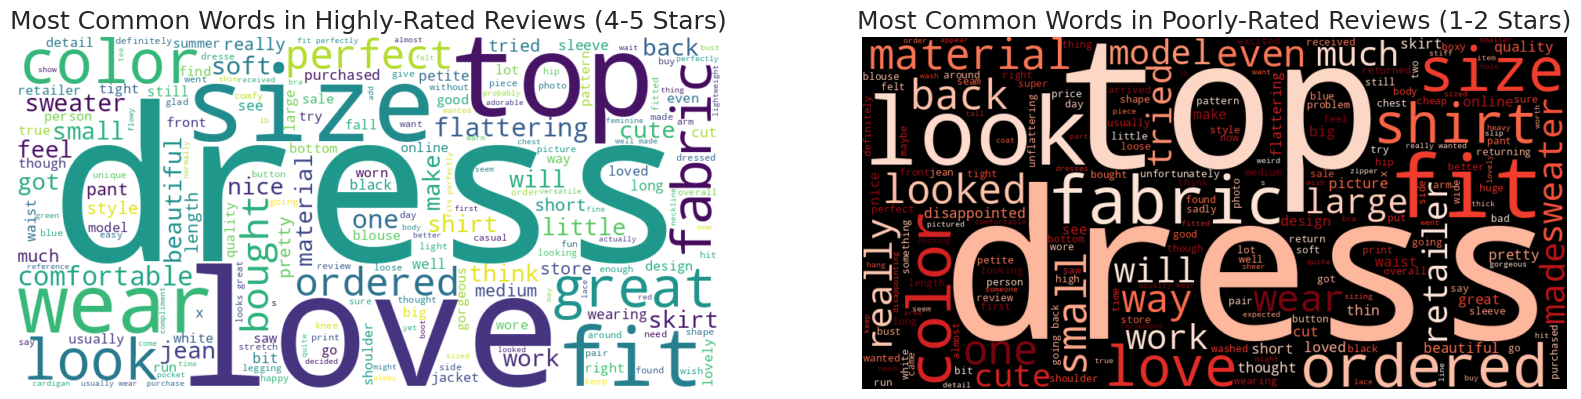

In [ ]:
# Word clouds for highly-rated versus poorly-rated reviews
positive_reviews = " ".join(df[df["Rating"].isin([4, 5])]["Review.Text"].astype(str))
negative_reviews = " ".join(df[df["Rating"].isin([1, 2])]["Review.Text"].astype(str))

wordcloud_positive = WordCloud(width=900, height=450, background_color="white").generate(positive_reviews)
wordcloud_negative = WordCloud(width=900, height=450, background_color="black", colormap="Reds").generate(negative_reviews)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
ax1.imshow(wordcloud_positive, interpolation="bilinear")
ax1.set_title("Most Common Words in Highly-Rated Reviews (4-5 Stars)", fontsize=18)
ax1.axis("off")

ax2.imshow(wordcloud_negative, interpolation="bilinear")
ax2.set_title("Most Common Words in Poorly-Rated Reviews (1-2 Stars)", fontsize=18)
ax2.axis("off")
plt.show()

In [ ]:
# Frequency table of most common words in positive and negative reviews
def top_terms(text_series, n=20):
    vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10)
    term_matrix = vectorizer.fit_transform(text_series.astype(str))
    frequencies = np.asarray(term_matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({"Term": terms, "Frequency": frequencies})
        .sort_values("Frequency", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

print("Top terms in highly-rated reviews (4-5 stars):")
display(top_terms(df[df["Rating"].isin([4, 5])]["Review.Text"]))

print("Top terms in poorly-rated reviews (1-2 stars):")
display(top_terms(df[df["Rating"].isin([1, 2])]["Review.Text"]))

Top terms in highly-rated reviews (4-5 stars):


,Term,Frequency
0,dress,8036
1,love,7742
2,size,7079
3,fit,5630
4,wear,5422
5,great,5417
6,like,4928
7,just,4011
8,color,3634
9,small,3531


Top terms in poorly-rated reviews (1-2 stars):


,Term,Frequency
0,dress,1123
1,like,1076
2,fabric,712
3,fit,687
4,size,677
5,just,667
6,small,518
7,look,516
8,ordered,512
9,really,474


**Word Cloud Interpretation and Initial Hypotheses**

Highly-rated reviews tend to contain words and phrases related to positive fit, emotional satisfaction, and styling appeal, such as love, great, perfect, fit, comfortable, flattering, size, dress, and wear. This suggests that customer satisfaction is driven by items that fit well, feel comfortable, look attractive, and match the customer's style expectations.

Poorly-rated reviews more often emphasize disappointment and mismatch, with recurring terms around fit, size, small, fabric, looked, quality, return, and wanted. This suggests dissatisfaction is often driven by sizing problems, poor fit, fabric or construction quality concerns, and gaps between product expectations and the actual item received.

An initial business hypothesis is that ChicStyle can improve customer satisfaction by strengthening size guidance, product images/descriptions, and fabric-quality controls. Fit and product expectation management appear to be the most important levers for reducing negative reviews.

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In Google Colab, store the API key in Colab secrets as `OPENAI_API_KEY`, retrieve it with `userdata.get("OPENAI_API_KEY")`, and pass it to the OpenAI client along with the Great Learning base URL. The model name should be stored once in `model_name` so every later cell uses the same model consistently.

In [ ]:
# Fetch API key
api_key = userdata.get('OPENAI_API_KEY')

# Initialize OpenAI client
client = openai.OpenAI(
    api_key=api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

model_name = "gpt-4o-mini"

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [ ]:
# Create a sample of 50 reviews to work with
df_sample_copy = df.sample(n=50, random_state=42).reset_index(drop=True)

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

A consistent evaluation framework is important because prompt outputs can vary in style, detail, and usefulness. Without a common rubric, comparisons across Zero-Shot, Few-Shot, and Chain-of-Thought prompts become subjective. An LLM-as-Judge can apply the same scoring criteria to every generated output and return a numeric score between 0 and 1 for relevance, sentiment correctness, structure, personalization, and business usefulness. The judge should be kept deterministic with temperature=0 and should be instructed to return only a score.

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?

3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

**Answers:**  

1.   A basic Zero-Shot prompt should directly ask the model to analyze the review and return exactly five labeled fields: `Category`, `Sentiment`, `Summary`, `Personalized Message`, and `Retail Insight`. The output format needs to be strict so the parser can extract the fields.
2.   The stronger V2 Zero-Shot prompt adds business context: ChicStyle is handling high-volume holiday feedback, accuracy matters for customer trust, and urgent product issues should be illuminated clearly. This helps the model produce more operationally useful summaries and insights.
3.   The notebook loops through the 50-review sample with `tqdm`, calls `generate_output(review, prompt)` for each review, converts the list of dictionaries into a DataFrame, prefixes the columns by prompt version, and concatenates the results back to `df_sample`.
4.   The LLM-as-Judge receives each review plus the generated structured output, applies the same rubric, returns a score from 0 to 1, and the average score is calculated for each prompt version.





In [ ]:
# Core LLM helper functions
STRUCTURED_FIELDS = ["Category", "Sentiment", "Summary", "Personalized_Message", "Retail_Insight"]


def call_chat_model(messages, model=model_name, temperature=0.0, max_tokens=350, max_retries=5, base_wait=2):
    """Wrapper with basic retry logic for transient API/rate-limit failures."""
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            return client.chat.completions.create(
                model=model,
                temperature=temperature,
                max_tokens=max_tokens,
                messages=messages
            )
        except Exception as e:
            last_error = e
            if attempt == max_retries:
                raise
            wait_time = min(base_wait * attempt, 15)
            print(f"Attempt {attempt}/{max_retries} failed with {type(e).__name__}. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)
    raise last_error


def get_structured_output(review_text: str, prompt: str) -> dict:
    empty_output = {
        "Category": "",
        "Sentiment": "",
        "Summary": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=350,
            messages=[
                {"role": "system", "content": "You are a precise retail feedback analyst. Return only the requested labeled fields."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        out = empty_output.copy()
        out["Summary"] = f"ERROR_CALL: {type(e).__name__}: {e}"
        out["Sentiment"] = "Error"
        return out

    text = resp.choices[0].message.content or ""
    out = empty_output.copy()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            key_map = {
                "category": "Category",
                "sentiment": "Sentiment",
                "summary": "Summary",
                "personalized message": "Personalized_Message",
                "personalized_message": "Personalized_Message",
                "retail insight": "Retail_Insight",
                "retail_insight": "Retail_Insight"
            }
            for key, value in parsed.items():
                normalized_key = str(key).strip().lower().replace("-", " ")
                if normalized_key in key_map:
                    out[key_map[normalized_key]] = str(value).strip()
            if any(out.values()):
                return out
    except Exception:
        pass

    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    for line in lines:
        line = re.sub(r"^[\-\*\d\.\)\s]+", "", line)
        if ":" not in line:
            continue
        key_raw, val = line.split(":", 1)
        key = key_raw.strip().lower().replace("_", " ")
        val = val.strip()
        if key.startswith("category"):
            out["Category"] = val
        elif key.startswith("sentiment"):
            out["Sentiment"] = val.title()
        elif key.startswith("summary"):
            out["Summary"] = val
        elif "personal" in key:
            out["Personalized_Message"] = val
        elif "insight" in key:
            out["Retail_Insight"] = val
    return out

In [ ]:
# Prompting strategies and evaluation framework
def generate_output(review_text, prompt):
    return get_structured_output(review_text, prompt)


def format_for_judge(row, prefix):
    return f"""
Review:
{row.get('Review.Text', '')}

Generated Output:
Category: {row.get(prefix + '_Category', '')}
Sentiment: {row.get(prefix + '_Sentiment', '')}
Summary: {row.get(prefix + '_Summary', '')}
Personalized Message: {row.get(prefix + '_Personalized_Message', '')}
Retail Insight: {row.get(prefix + '_Retail_Insight', '')}
""".strip()


judge_prompt = """
You are an impartial evaluator for a retail feedback intelligence system.
Score the generated output against the original review.

Rubric:
- 0.20 correct sentiment and tone interpretation
- 0.20 useful business category
- 0.20 accurate and concise summary
- 0.20 empathetic, specific personalized message
- 0.20 actionable retail insight

Return only one decimal number from 0 to 1. Do not include words, bullets, or explanations.

{output}
"""


def judge_output(output_text):
    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0,
            max_tokens=10,
            messages=[
                {"role": "system", "content": "You are a strict evaluator that returns only a numeric score."},
                {"role": "user", "content": judge_prompt.format(output=output_text)}
            ]
        )
        score_str = resp.choices[0].message.content.strip()
        match = re.search(r"0(?:\.\d+)?|1(?:\.0+)?", score_str)
        if not match:
            return None
        return max(0.0, min(1.0, float(match.group(0))))
    except Exception:
        return None


def parse_success_rate(df_frame, prefix):
    required_cols = [
        f"{prefix}_Category",
        f"{prefix}_Sentiment",
        f"{prefix}_Summary",
        f"{prefix}_Personalized_Message",
        f"{prefix}_Retail_Insight"
    ]
    return df_frame[required_cols].fillna("").apply(
        lambda row: all(str(v).strip() != "" for v in row), axis=1
    ).mean()

In [ ]:
print("Zero-Shot Version 1 predictions:")
df_sample = df_sample_copy.copy()

# Define the first version of your Zero-Shot prompt.
zero_shot_prompt_v1 = """Analyze the customer review and return exactly five lines in this format:
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""


# Loop through each review in the sample, call the generate_output function, and store the results.
zs_list = [generate_output(review, zero_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot Predictions")]
zs_df = pd.DataFrame(zs_list)
df_sample = pd.concat([df_sample, zs_df.add_prefix("ZS_V1_")], axis=1)
df_sample.head()

Zero-Shot Version 1 predictions:


Zero-Shot Predictions: 100%|██████████| 50/50 [01:36<00:00,  1.93s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Personalized_Message,ZS_V1_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,Fit and Design,Positive,The customer praises the sweater for its flattering fit and beautiful design.,We're thrilled to hear that you love the fit and style of your new sweater!,Highlight the true-to-size fit in product descriptions to assist customers in making informed sizing decisions.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,Fit and Texture,Neutral,The customer appreciates the design but finds the fit and texture unsatisfactory.,We understand how important the right fit and texture are for your comfort and style.,Consider offering a size guide and fabric details to help customers make more informed choices.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,Sizing Issues,Neutral,The customer enjoys the blouse but finds it too tight in certain areas and is returning it for a larger size.,We appreciate your feedback and understand how important the right fit is for your comfort.,Consider offering a more detailed sizing guide or additional size options to accommodate different body types.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,Fit and Comfort,Positive,"The customer appreciates the lightweight, soft fabric and flattering fit of the summer pants.",We're thrilled to hear that our pants provide the perfect blend of comfort and style for you!,Highlight the versatility and flattering fit of the pants in marketing to attract customers looking for both comfort and style.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans from the 90's that just fit terribly. i thought...,2,1,4,General,Bottoms,Jeans,Product Misrepresentation,Negative,The customer is disappointed with the fit and color of the jeans compared to the online image.,"We understand how frustrating it can be when a product doesn't meet your expectations, and we appreciate your feedback.",Improve product images and descriptions to better reflect the actual fit and color to reduce return rates.


In [ ]:
print("Judgement of Zero-Shot V1 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
zs_scores = [
    judge_output(format_for_judge(row, "ZS_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge ZS_V1")
]
df_sample["ZS_V1_Score"] = zs_scores
print(f"Avg ZS_V1_Score: {df_sample['ZS_V1_Score'].mean():.3f}")

Judgement of Zero-Shot V1 outputs:


Judge ZS_V1: 100%|██████████| 50/50 [00:42<00:00,  1.19it/s]

Avg ZS_V1_Score: 0.918


In [ ]:
print("Zero-Shot V2 predictions (context-enhanced):")

# Define the second version of your Zero-Shot prompt.
zero_shot_prompt_v2 = """You are analyzing real-time holiday-season reviews for
ChicStyle, a fashion retail platform. Accuracy matters because delayed or
incorrect review handling can damage customer trust during peak sales periods.

Classify the review using retail business context. Prioritize issues related to
fit, sizing, product quality, comfort, color/image mismatch, delivery/service,
and value. If a review contains mixed feedback, choose Neutral unless the
overall tone clearly leans positive or negative.

Return exactly five lines and no extra commentary:
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one concise sentence grounded in the review>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one action ChicStyle can take or monitor>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
zsv2_list = [generate_output(review, zero_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot V2 Predictions")]
zsv2_df = pd.DataFrame(zsv2_list)
df_sample = pd.concat([df_sample, zsv2_df.add_prefix("ZS_V2_")], axis=1)
df_sample.head()

Zero-Shot V2 predictions (context-enhanced):


Zero-Shot V2 Predictions: 100%|██████████| 50/50 [01:28<00:00,  1.77s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Personalized_Message,ZS_V1_Retail_Insight,ZS_V1_Score,ZS_V2_Category,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Personalized_Message,ZS_V2_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,...,Positive,The customer praises the sweater for its flattering fit and beautiful design.,We're thrilled to hear that you love the fit and style of your new sweater!,Highlight the true-to-size fit in product descriptions to assist customers in making informed sizing decisions.,1.0,Fit,Positive,"The sweater fits perfectly and is flattering, with a beautiful design.",We're thrilled to hear that the sweater fits you so well and enhances your look!,ChicStyle should highlight fit information and customer recommendations for sizing in product descriptions.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,...,Neutral,The customer appreciates the design but finds the fit and texture unsatisfactory.,We understand how important the right fit and texture are for your comfort and style.,Consider offering a size guide and fabric details to help customers make more informed choices.,0.8,Fit,Neutral,The reviewer found the sizing of the XS white version to be slightly large but appreciated the color and design details.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback on the sizing.",ChicStyle should consider providing more detailed sizing information and customer reviews to help shoppers make informed decisions.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,...,Neutral,The customer enjoys the blouse but finds it too tight in certain areas and is returning it for a larger size.,We appreciate your feedback and understand how important the right fit is for your comfort.,Consider offering a more detailed sizing guide or additional size options to accommodate different body types.,0.8,Fit/Sizing,Neutral,The blouse is liked but is being returned due to sizing issues in the upper arms and chest.,"We understand how frustrating it can be to find the right fit, and we appreciate your feedback.",ChicStyle should consider providing detailed sizing charts and fit guides to help customers choose the right size.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,...,Positive,"The customer appreciates the lightweight, soft fabric and flattering fit of the summer pants.",We're thrilled to hear that our pants provide the perfect blend of comfort and style for you!,Highlight the versatility and flattering fit of the pants in marketing to attract customers looking for both comfort and style.,1.0,Fit,Positive,The reviewer appreciates the lightweight fabric and perfect fit of the summer pants.,We're thrilled to hear that our summer pants provide the perfect balance of comfort and style for you!,ChicStyle should highlight the fit options and fabric details in product descriptions to attract similar customers.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans from the 90's that just fit terribly. i though

In [ ]:
print("Judging Zero-Shot V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
zsv2_scores = [
    judge_output(format_for_judge(row, "ZS_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge ZS_V2")
]
df_sample["ZS_V2_Score"] = zsv2_scores
print(f"Avg ZS_V2_Score: {df_sample['ZS_V2_Score'].mean():.3f}")

Judging Zero-Shot V2 outputs:


Judge ZS_V2: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]

Avg ZS_V2_Score: 0.860


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?


    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?


    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?



**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

**Answers:**  

1.   A Few-Shot prompt should include the task instructions plus a small set of high-quality examples showing the desired input-output pattern. The best examples are representative and contrasting: at least one clearly positive review, one clearly negative review, and one mixed/neutral review. This teaches the model both the desired labels and exact output structure.
2.   The V2 prompt can add explicit rules for each field: choose one dominant category, use only Positive/Negative/Neutral for sentiment, keep the summary factual, make the personalized message empathetic but not overpromising, and make actionable retail insights for merchandising, product, or customer experience teams.
3.  Few-Shot prompting performed well, but not better than the best Zero-Shot version. Few-Shot V1 scored 0.908 and Few-Shot V2 scored 0.892, both higher than Zero-Shot V2 (0.860) but lower than Zero-Shot V1 (0.918). This shows that Few-Shot prompting was effective, but the simplest prompt, Zero-Shot V1, still worked best.



In [ ]:
print("Few-Shot V1 predictions:")

# Define V1 of the Few-Shot prompt.
few_shot_prompt_v1 = """Analyze the customer review and return the same five fields shown in the examples.

Example 1
Review: Love this dress. It fits perfectly and the fabric feels soft.
Category: Fit and Comfort
Sentiment: Positive
Summary: The customer loves the dress because it fits well and feels comfortable.
Personalized Message: Thank you for sharing your experience; we are glad the fit and fabric worked so well for you.
Retail Insight: Fit and fabric comfort are strong selling points for this item.

Example 2
Review: I wanted to love this top, but it ran very small and the fabric felt cheap.
Category: Fit/Sizing and Product Quality
Sentiment: Negative
Summary: The customer is disappointed because the item ran small and the fabric quality felt poor.
Personalized Message: We are sorry the top did not meet expectations and appreciate the feedback on sizing and fabric.
Retail Insight: Review sizing guidance and fabric quality for this product.

Example 3
Review: The sweater is cute and soft, but the sleeves stretched out after one wear.
Category: Product Quality and Comfort
Sentiment: Neutral
Summary: The customer liked the sweater's look and softness but noticed sleeve stretching after one wear.

Now analyze the new review. Return exactly five lines:
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_list = [generate_output(review, few_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V1 Predictions")]
fs_df = pd.DataFrame(fs_list)
df_sample = pd.concat([df_sample, fs_df.add_prefix("FS_V1_")], axis=1)
df_sample.head()

Few-Shot V1 predictions:


Few-Shot V1 Predictions: 100%|██████████| 50/50 [01:45<00:00,  2.11s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Personalized_Message,ZS_V2_Retail_Insight,ZS_V2_Score,FS_V1_Category,FS_V1_Sentiment,FS_V1_Summary,FS_V1_Personalized_Message,FS_V1_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,...,Positive,"The sweater fits perfectly and is flattering, with a beautiful design.",We're thrilled to hear that the sweater fits you so well and enhances your look!,ChicStyle should highlight fit information and customer recommendations for sizing in product descriptions.,1.0,Fit and Design,Positive,"The customer finds the sweater beautiful, flattering, and true to size.",Thank you for your wonderful feedback; we're thrilled to hear the sweater fits perfectly and looks great on you!,Highlight the flattering design and true-to-size fit in marketing materials.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,...,Neutral,The reviewer found the sizing of the XS white version to be slightly large but appreciated the color and design details.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback on the sizing.",ChicStyle should consider providing more detailed sizing information and customer reviews to help shoppers make informed decisions.,0.8,Fit/Sizing and Product Quality,Mixed,The customer appreciates the color and design but finds the fit too large and dislikes the texture of the spandex.,Thank you for your feedback; we’re glad you liked the colors but are sorry to hear about the fit and texture issues.,Consider providing more detailed sizing information and evaluating the fabric texture for improvement.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,...,Neutral,The blouse is liked but is being returned due to sizing issues in the upper arms and chest.,"We understand how frustrating it can be to find the right fit, and we appreciate your feedback.",ChicStyle should consider providing detailed sizing charts and fit guides to help customers choose the right size.,0.8,Fit/Sizing,Neutral,The customer likes the blouse but is returning it due to sizing issues in the upper arms and chest.,We appreciate your feedback and understand the importance of finding the right fit.,Consider providing more detailed sizing information to help customers choose the correct size.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,...,Positive,The reviewer appreciates the lightweight fabric and perfect fit of the summer pants.,We're thrilled to hear that our summer pants provide the perfect balance of comfort and style for you!,ChicStyle should highlight the fit options and fabric details in product descriptions to attract similar customers.,0.9,Fit and Comfort,Positive,"The customer finds the pants perfect for a relaxed summer look, appreciating their softness and fit.",Thank you for your wonderful feedback; we're thrilled the pants provide the comfort and style you were looking for!,Highlight the versatility and comfort of these pants in marketing to attract similar customers.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as

In [ ]:
print("Judgement of Few-Shot V1 outputs:")

# Loop through the generated outputs and use the judge_output function to score them.
fs_v1_scores = [
    judge_output(format_for_judge(row, "FS_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge FS_V1")
]
df_sample["FS_V1_Score"] = fs_v1_scores
print(f"Avg FS_V1_Score: {df_sample['FS_V1_Score'].mean():.3f}")

Judgement of Few-Shot V1 outputs:


Judge FS_V1: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]

Avg FS_V1_Score: 0.908


In [ ]:
print("Few-Shot V2 predictions (context-enhanced):")

# Define the second version of your few-Shot prompt.
few_shot_prompt_v2 = """You are ChicStyle's retail feedback analyst. Use the examples and rules below to produce consistent structured outputs.

Rules:
1. Category must be specific, such as Fit/Sizing, Product Quality, Style/Design, Comfort, Color/Image Accuracy, Delivery/Service, Price/Value, or General Experience.
2. Sentiment must be exactly Positive, Negative, or Neutral. Use Neutral for mixed reviews with balanced praise and criticism.
3. Summary must be factual and no more than 25 words.
4. Personalized Message must acknowledge the customer's exact experience and avoid offering refunds or policies not stated in the review.
5. Retail Insight must be an action or monitoring recommendation for the business.

Example 1
Review: This jacket is beautiful, warm, and true to size. I received many compliments.
Category: Style/Design and Fit/Sizing
Sentiment: Positive
Summary: The customer liked the jacket's style, warmth, and true-to-size fit.
Personalized Message: We are delighted that the jacket fit well and brought you compliments.
Retail Insight: Highlight warmth, fit accuracy, and styling in product messaging.

Example 2
Review: The pants looked nothing like the photo and were too tight in the waist.
Category: Color/Image Accuracy and Fit/Sizing
Sentiment: Negative
Summary: The customer felt the pants did not match the photo and were too tight.
Personalized Message: We are sorry the pants did not match your expectations in appearance or fit.
Retail Insight: Audit product photos and waist-fit guidance for this item.

Example 3
Review: The sweater is cute and soft, but the sleeves stretched out after one wear.
Category: Product Quality and Comfort
Sentiment: Neutral
Summary: The customer liked the sweater's look and softness but noticed sleeve stretching after one wear.
Personalized Message: Thank you for noting both the comfort and the sleeve durability concern.
Retail Insight: Investigate sleeve recovery and fabric durability while preserving softness.

Now analyze the new review. Return exactly five lines and no extra text:
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_v2_list = [generate_output(review, few_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V2 Predictions")]
fs_v2_df = pd.DataFrame(fs_v2_list)
df_sample = pd.concat([df_sample, fs_v2_df.add_prefix("FS_V2_")], axis=1)

Few-Shot V2 predictions (context-enhanced):


Few-Shot V2 Predictions: 100%|██████████| 50/50 [01:51<00:00,  2.23s/it]


In [ ]:
print("Judgement of Few-Shot V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
fs_v2_scores = [
    judge_output(format_for_judge(row, "FS_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge FS_V2")
]
df_sample["FS_V2_Score"] = fs_v2_scores
print(f"Avg FS_V2_Score: {df_sample['FS_V2_Score'].mean():.3f}")

Judgement of Few-Shot V2 outputs:


Judge FS_V2: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]

Avg FS_V2_Score: 0.892


#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

**Answers:**  

1. The prompt should instruct the model to reason internally before answering, but it should also explicitly say: "Do not show your reasoning. Return only the final structured answer." This gets the benefit of deliberate analysis without exposing verbose reasoning or breaking the parser.

2. CoT V2 can combine internal reasoning with the stronger business context and field-level rules from the enhanced prompts. The model can silently check the review for sentiment, main issue, urgency, customer impact, and business action before returning the five required lines.

3. Yes. CoT V2 scored 0.912, compared with 0.892 for CoT V1, showing a measurable improvement. This suggests that encouraging the model to reason first, especially with a better-structured prompt, helped produce higher-quality and more useful insights.



In [ ]:
print("CoT V1 predictions:")

# Define the first version of your COT prompt.
cot_prompt_v1 = """Analyze the review by thinking through the customer's main issue, sentiment, and business implication internally. Do not reveal your reasoning.

Return only the final answer in exactly five lines:
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_list = [generate_output(review, cot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="CoT V1 Predictions")]
cot_df = pd.DataFrame(cot_list)
df_sample = pd.concat([df_sample, cot_df.add_prefix("COT_V1_")], axis=1)

CoT V1 predictions:


CoT V1 Predictions: 100%|██████████| 50/50 [01:32<00:00,  1.84s/it]


In [ ]:
print("Judgement of CoT V1 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
cot_v1_scores = [
    judge_output(format_for_judge(row, "COT_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge COT_V1")
]
df_sample["COT_V1_Score"] = cot_v1_scores
print(f"Avg COT_V1_Score: {df_sample['COT_V1_Score'].mean():.3f}")

Judgement of CoT V1 outputs:


Judge COT_V1: 100%|██████████| 50/50 [00:41<00:00,  1.19it/s]

Avg COT_V1_Score: 0.892


In [ ]:
print("CoT V2 predictions (context-enhanced):")
# Define the second version of the CoT prompt.
cot_prompt_v2 = """You are ChicStyle's real-time retail feedback analyst during a high-volume holiday sales period.

Before answering, reason internally through these steps:
1. Identify whether the review is mainly about fit/sizing, quality, style/design, comfort, color/image accuracy, delivery/service, price/value, or general experience.
2. Determine whether the overall sentiment is Positive, Negative, or Neutral, treating balanced mixed feedback as Neutral.
3. Separate the customer's emotional concern from the operational business issue.
4. Decide what the customer support team should acknowledge and what the merchandising/product team should learn.

Do not show the reasoning. Return exactly five lines and no extra commentary:
Category: <specific business category>
Sentiment: <Positive, Negative, or Neutral>
Summary: <one factual sentence of 25 words or fewer>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight for ChicStyle>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_v2_list = [generate_output(review, cot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="CoT V2 Predictions")]
cot_v2_df = pd.DataFrame(cot_v2_list)
df_sample = pd.concat([df_sample, cot_v2_df.add_prefix("COT_V2_")], axis=1)

CoT V2 predictions (context-enhanced):


CoT V2 Predictions: 100%|██████████| 50/50 [01:45<00:00,  2.10s/it]


In [ ]:
print("Judgement of CoT V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
cot_v2_scores = [
    judge_output(format_for_judge(row, "COT_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge COT_V2")
]
df_sample["COT_V2_Score"] = cot_v2_scores
print(f"Avg COT_V2_Score: {df_sample['COT_V2_Score'].mean():.3f}")

Judgement of CoT V2 outputs:


Judge COT_V2: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]

Avg COT_V2_Score: 0.912


## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

**Answers:**

1. The recommendation prompt should be strict and short. It should tell the model to use only the review text and return exactly two lines: `Recommended: 1` or `Recommended: 0`, followed by `Reason: <brief reason>`. This reduces parsing errors and avoids long narrative responses.

2. A regex-based parsing function is needed to reliably extract the binary flag and reason even if the model adds small formatting variations. The parser should return `(flag, reason, raw_text)` and use `np.nan` if no valid 0/1 flag is found.

3. The predictions should be compared with the original human label using standard classification metrics: `accuracy_score` for overall correctness, `confusion_matrix` for false positives/false negatives, and `classification_report` for precision, recall, and F1-score.

In [ ]:
# Predict product recommendations
df_reco = df_sample.copy()
df_reco["Actual_Recommended"] = df_reco["Recommended.IND"]
df_reco = df_reco.drop(columns=["Recommended.IND"])

In [ ]:
# Recommendation prompt
recommendation_prompt = """
Predict whether the customer would recommend the product based only on the review text.

Return exactly two lines:
Recommended: <1 if the customer would recommend, otherwise 0>
Reason: <brief reason using 20 words or fewer>

Rules:
- Use 1 for clearly positive or recommendable experiences.
- Use 0 for clearly negative experiences, returns, poor fit, defects, misleading photos, or strong dissatisfaction.
- For mixed reviews, choose the label that best matches the customer's overall likelihood to recommend.
- Do not include any extra text.
"""

In [ ]:
def parse_recommendation_reply(raw_text):
    if raw_text is None: return (np.nan, "", "")
    s = str(raw_text).strip()
    m = re.search(r'Recommended\s*:\s*([01])\b', s, re.IGNORECASE)
    flag = int(m.group(1)) if m else np.nan
    m3 = re.search(r'Reason\s*:\s*(.+)', s, re.IGNORECASE)
    reason = m3.group(1).strip() if m3 else ""
    return (flag, reason[:200], s)

llm_preds = []
for review in tqdm(df_reco["Review.Text"], desc="LLM Recommend Predictions"):
    prompt = recommendation_prompt + "\n\nReview:\n" + (review or "")
    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=60,
            messages=[{"role":"user", "content": prompt}]
        )
        raw = resp.choices[0].message.content or ""
    except Exception as e:
        raw = f"ERROR: {type(e).__name__}: {e}"

    flag, reason, raw_clean = parse_recommendation_reply(raw)
    llm_preds.append({
        "LLM_Recommended_Raw": raw_clean,
        "LLM_Recommended_Flag": flag,
        "LLM_Recommend_Reason": reason
    })

llm_pred_df = pd.DataFrame(llm_preds)
df_reco = pd.concat([df_reco.reset_index(drop=True), llm_pred_df.reset_index(drop=True)], axis=1)

LLM Recommend Predictions: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


In [ ]:
# Model Performance Evaluation
eval_df = df_reco.dropna(subset=["LLM_Recommended_Flag"]).copy()
if not eval_df.empty:
    y_true = eval_df["Actual_Recommended"].astype(int)
    y_pred = eval_df["LLM_Recommended_Flag"].astype(int)

    # Calculate the accuracy score.
    acc = accuracy_score(y_true, y_pred)
    # Generate the confusion matrix.
    cm = confusion_matrix(y_true, y_pred)
    # Generate the classification report.
    report = classification_report(y_true, y_pred, digits=3)

    print(f"Accuracy: {acc:.3f}\n")
    print("Confusion Matrix:\n", cm)
    print("\nClassification report:\n", report)
else:
    print("No valid LLM recommendation predictions were available for evaluation.")

Accuracy: 0.800

Confusion Matrix:
 [[12  0]
 [10 28]]

Classification report:
               precision    recall  f1-score   support

           0      0.545     1.000     0.706        12
           1      1.000     0.737     0.848        38

    accuracy                          0.800        50
   macro avg      0.773     0.868     0.777        50
weighted avg      0.891     0.800     0.814        50



In [ ]:
# Store the explanation prompt template in a variable for {human_label} and {llm_label} to be input later.
explain_prompt = """
The human recommendation label is {human_label}, but the LLM predicted {llm_label}.
Explain the likely reason for this mismatch in one concise sentence.
Focus on ambiguity, mixed sentiment, missing context, or wording in the review.
"""

diff_rows = df_reco[
    (df_reco["LLM_Recommended_Flag"].notna()) &
    (df_reco["LLM_Recommended_Flag"].astype(float) != df_reco["Actual_Recommended"].astype(float))
]

explanations = []
for idx, row in tqdm(diff_rows.iterrows(), total=len(diff_rows), desc="Explain mismatches"):
    review = row.get("Review.Text", "") or ""
    llm_label = int(row.get("LLM_Recommended_Flag"))
    human_label = int(row.get("Actual_Recommended"))
    prompt = explain_prompt.format(human_label=human_label, llm_label=llm_label) + "\n\nReview:\n" + review

    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=40,
            messages=[
                {"role": "system", "content": "You are a concise analyst."},
                {"role": "user", "content": prompt}
            ]
        )
        raw = (resp.choices[0].message.content or "").strip().replace("\n", " ")
        explanations.append(raw[:250])
    except Exception as e:
        explanations.append(f"ERROR: {type(e).__name__}")

df_reco["LLM_Diff_Explain"] = ""
for i, idx in enumerate(diff_rows.index):
    df_reco.at[idx, "LLM_Diff_Explain"] = explanations[i]

print(f"Added explanations for {len(diff_rows)} mismatches.")
df_reco.head()

Explain mismatches: 100%|██████████| 10/10 [00:13<00:00,  1.36s/it]

Added explanations for 10 mismatches.


,Clothing.ID,Age,Title,Review.Text,Rating,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,...,COT_V2_Sentiment,COT_V2_Summary,COT_V2_Personalized_Message,COT_V2_Retail_Insight,COT_V2_Score,Actual_Recommended,LLM_Recommended_Raw,LLM_Recommended_Flag,LLM_Recommend_Reason,LLM_Diff_Explain
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,4,General,Tops,Sweaters,Fit and Design,...,Positive,"The customer praises the sweater's beautiful design, flattering fit, and true-to-size measurements.",We're thrilled to hear that you love the sweater and found the fit perfect!,Highlight the true-to-size fit in product descriptions to assist customers in making informed purchasing decisions.,1.0,1,"Recommended: 1 \nReason: The customer loves the fit and design, strongly encouraging others to purchase the sweater.",1,"The customer loves the fit and design, strongly encouraging others to purchase the sweater.",
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,38,General,Tops,Knits,Fit and Texture,...,Neutral,The customer appreciates the color and design but finds the fit too large and dislikes the texture of the fabric.,"We appreciate your feedback on the fit and texture, and we're glad you liked the color contrast!",Consider adjusting the sizing guide and fabric descriptions to better align customer expectations with product characteristics.,0.8,1,"Recommended: 0 \nReason: The customer has mixed feelings and mentions dissatisfaction with the texture, indicating a lack of overall recommendation.",0,"The customer has mixed feelings and mentions dissatisfaction with the texture, indicating a lack of overall recommendation.","The mismatch likely arises from the mixed sentiment in the review, where positive comments about the design and color contrast are overshadowed by a negative remark about the texture, leading the ..."
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,0,General,Tops,Blouses,Sizing Issues,...,Neutral,"The customer likes the blouse but finds it too tight in the upper arms and chest, prompting a return for a larger size.",We appreciate your feedback and understand the importance of finding the perfect fit.,Consider offering more size options or a fit guide to help customers choose the right size.,0.8,1,"Recommended: 0 \nReason: The customer is returning the blouse due to fit issues, indicating dissatisfaction.",0,"The customer is returning the blouse due to fit issues, indicating dissatisfaction.","The mismatch likely arises from the mixed sentiment in the review, where the positive expression of liking the blouse is overshadowed by the negative comments about fit, leading the LLM to misinte..."
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,0,General Petite,Bottoms,Pants,Fit and Comfort,...,Positive,The customer appreciates the lightweight fabric and flattering fit of the summer pants.,We're thrilled to hear that our summer pants provide the perfect balance of comfort and style for you!,Highlight the versatility of fit options in product descriptions to attract customers seeking both relaxed and fitted styles.,0.9,1,"Recommended: 1 \nReason: The customer appreciates the fit, comfort, and style of the pants, indicating a positive experience.",1,"The customer appreciates the fit, comfort, and style of the pants, indicating a positive experience.",
4,1030,44,Terrible

**Interpretation:**

- **Accuracy:** The model correctly predicted the recommendation status for 80% of the reviews.
- **Precision for class 0 (Not Recommended):** 0.545. When the model predicts a product is not recommended, it is correct 54.5% of the time.
- **Recall for class 0 (Not Recommended):** 1.000. The model correctly identified all actual 'not recommended' cases (12 out of 12).
- **Precision for class 1 (Recommended):** 1.000. When the model predicts a product is recommended, it is correct 100% of the time (it had no false positives).
- **Recall for class 1 (Recommended):** 0.737. The model correctly identified 73.7% of all actual 'recommended' cases (28 out of 38).

**Overall:** The model is excellent at identifying 'recommended' products without false positives, but it struggles with false negatives for 'not recommended' products, meaning it sometimes misses actual 'not recommended' cases and labels them as 'recommended'. This suggests that the model is biased towards predicting 'recommended', which could be due to the imbalanced nature of the dataset (38 recommended vs 12 not recommended).

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).  

    The three V2 prompting techniques show broadly similar sentiment patterns, but with some meaningful differences. Few-Shot V2 is the most balanced, with 24 Positive, 11 Negative, and 15 Neutral predictions, suggesting it is slightly more cautious and better at recognizing mixed feedback. Zero-Shot V2 is also fairly balanced, with 22 Positive, 14 Negative, and 14 Neutral predictions. In contrast, CoT V2 predicts the highest number of Positive reviews (27) and the lowest number of Neutral reviews (9), which suggests it was more decisive and less likely to classify reviews as mixed. Overall, Few-Shot V2 and Zero-Shot V2 appear more conservative, while CoT V2 leans more strongly toward positive sentiment.
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?  

    Yes, there are noticeable differences. The V2 prompts, especially Few-Shot V2 (15 Neutral) and Zero-Shot V2 (14 Neutral), identify more Neutral reviews than the V1 versions, where Neutral counts are much lower (6 to 7). CoT V2 is less cautious than those two, with 9 Neutral reviews, while the V1 prompts generally lean more positive and assign fewer mixed or neutral labels.

    This suggests that Few-Shot V2 and Zero-Shot V2 are better at capturing nuance and recognizing balanced or mixed feedback instead of forcing a clearly positive or negative label. In contrast, the V1 prompts appear more decisive and slightly more biased toward positive sentiment. CoT V2 sits in between: it recognizes some nuance, but it is still more likely to commit to a clear sentiment than the other V2 versions.
    


In [ ]:
# Helper function for bar chart
def normalize_sentiment(value):
    text = str(value).strip().lower()
    if "positive" in text:
        return "Positive"
    if "negative" in text:
        return "Negative"
    if "neutral" in text:
        return "Neutral"
    if text in {"", "nan", "none"}:
        return "Missing"
    return text.title()


def plot_sentiment(df_frame, column_name, title):
    sentiment_counts = df_frame[column_name].apply(normalize_sentiment).value_counts().reset_index()
    sentiment_counts.columns = ["Sentiment", "Count"]

    fig = px.bar(
        sentiment_counts,
        x="Sentiment",
        y="Count",
        text="Count",
        title=title,
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(xaxis_title="Sentiment", yaxis_title="Count")
    fig.show()

In [ ]:
# Plot V1 sentiment distributions
plot_sentiment(df_sample, "ZS_V1_Sentiment", "Zero-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "FS_V1_Sentiment", "Few-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "COT_V1_Sentiment", "Chain-of-Thought Sentiment Distribution for Version 1")

In [ ]:
# Plot the V2 sentiment distributions
plot_sentiment(df_sample, "ZS_V2_Sentiment", "Zero-Shot V2 Sentiment Distribution")
plot_sentiment(df_sample, "FS_V2_Sentiment", "Few-Shot V2 Sentiment Distribution")
plot_sentiment(df_sample, "COT_V2_Sentiment", "Chain-of-Thought V2 Sentiment Distribution")

In [ ]:
# Compare average judge scores across all prompt versions.
score_columns = [
    "ZS_V1_Score", "ZS_V2_Score",
    "FS_V1_Score", "FS_V2_Score",
    "COT_V1_Score", "COT_V2_Score"
]
score_means = df_sample[score_columns].apply(pd.to_numeric, errors="coerce").mean().reset_index()
score_means.columns = ["Prompt_Version", "Average_Judge_Score"]

fig_scores = px.bar(
    score_means,
    x="Prompt_Version",
    y="Average_Judge_Score",
    text="Average_Judge_Score",
    title="Average LLM-as-Judge Score by Prompt Version",
    color="Average_Judge_Score"
)
fig_scores.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_scores.update_layout(yaxis_title="Average Judge Score")
fig_scores.show()

##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [ ]:
# Quantitative comparison of all techniques

comparison_summary = pd.DataFrame({
    "Prompt_Version": ["ZS_V1", "ZS_V2", "FS_V1", "FS_V2", "COT_V1", "COT_V2"],
    "Average_Judge_Score": [
        df_sample["ZS_V1_Score"].mean(),
        df_sample["ZS_V2_Score"].mean(),
        df_sample["FS_V1_Score"].mean(),
        df_sample["FS_V2_Score"].mean(),
        df_sample["COT_V1_Score"].mean(),
        df_sample["COT_V2_Score"].mean(),
    ],
    "Parse_Success_Rate": [
        parse_success_rate(df_sample, "ZS_V1"),
        parse_success_rate(df_sample, "ZS_V2"),
        parse_success_rate(df_sample, "FS_V1"),
        parse_success_rate(df_sample, "FS_V2"),
        parse_success_rate(df_sample, "COT_V1"),
        parse_success_rate(df_sample, "COT_V2"),
    ]
}).sort_values("Average_Judge_Score", ascending=False).reset_index(drop=True)

display(comparison_summary.style.format({
    "Average_Judge_Score": "{:.3f}",
    "Parse_Success_Rate": "{:.1%}"
}))

best_prefix = comparison_summary.loc[0, "Prompt_Version"]
print(f"Best prompt version based on average judge score: {best_prefix}")

comparison_records = []
for _, row in df_sample.iterrows():
    comparison_records.append({
        "Review": row.get("Review.Text", ""),
        "ZS_V1_Sentiment": row.get("ZS_V1_Sentiment", None),
        "ZS_V2_Sentiment": row.get("ZS_V2_Sentiment", None),
        "FS_V1_Sentiment": row.get("FS_V1_Sentiment", None),
        "FS_V2_Sentiment": row.get("FS_V2_Sentiment", None),
        "COT_V1_Sentiment": row.get("COT_V1_Sentiment", None),
        "COT_V2_Sentiment": row.get("COT_V2_Sentiment", None),
    })

compare_prompt = f"""
You are evaluating six prompt versions for retail review intelligence.

Quantitative performance summary:
{comparison_summary.to_string(index=False)}

Per-review sentiment comparison records:
{json.dumps(comparison_records, indent=2)}

Tasks:
1. Compare each prompt version in terms of sentiment consistency, structure
quality, and business usefulness: ZS_V1, ZS_V2, FS_V1, FS_V2, COT_V1, and COT_V2.
2. Identify which specific version appears most reliable and explain why.
3. Comment on whether adding business context improved or hurt V2 over V1 for each prompting family.
4. Recommend the best final production prompt design.

Keep the answer concise but decision-ready.
"""

response = call_chat_model(
    model=model_name,
    temperature=0,
    max_tokens=600,
    messages=[
        {"role": "system", "content": "You are an expert in evaluating LLM prompting strategies."},
        {"role": "user", "content": compare_prompt}
    ]
)
print(response.choices[0].message.content)

,Prompt_Version,Average_Judge_Score,Parse_Success_Rate
0,ZS_V1,0.918,100.0%
1,COT_V2,0.912,100.0%
2,FS_V1,0.908,100.0%
3,FS_V2,0.892,100.0%
4,COT_V1,0.892,100.0%
5,ZS_V2,0.860,100.0%


Best prompt version based on average judge score: ZS_V1
### 1. Comparison of Prompt Versions

**Sentiment Consistency:**
- **ZS_V1 & ZS_V2:** Both versions show high consistency in sentiment classification across reviews, with minor variations in neutral and mixed sentiments. ZS_V1 maintains a slightly higher positive sentiment classification.
- **FS_V1 & FS_V2:** FS_V1 shows a good balance of sentiment classification, but FS_V2 has a few more neutral and mixed classifications, indicating less consistency.
- **COT_V1 & COT_V2:** COT_V1 has a notable inconsistency, particularly in the third review where it classified a neutral sentiment as negative. COT_V2 improves on this but still shows some variability.

**Structure Quality:**
- **ZS_V1 & ZS_V2:** Both versions are well-structured, providing clear sentiment outputs. ZS_V1 is slightly more concise.
- **FS_V1 & FS_V2:** FS_V1 is structured well, but FS_V2 has some redundancy in sentiment classification, which may confuse users.
- **COT

**Comparison of Prompt Versions**

**Sentiment Consistency:**
- **ZS_V1 & ZS_V2:** Both versions show high consistency in sentiment classification across reviews, with minor variations in neutral and mixed sentiments. ZS_V1 maintains a slightly higher positive sentiment classification.
- **FS_V1 & FS_V2:** FS_V1 shows a good balance of sentiment classification, but FS_V2 has a few more neutral and mixed classifications, indicating less consistency.
- **COT_V1 & COT_V2:** COT_V1 has a notable inconsistency, particularly in the third review where it classified a neutral sentiment as negative. COT_V2 improves on this but still shows some variability.

**Structure Quality:**
- **ZS_V1 & ZS_V2:** Both versions are well-structured, providing clear sentiment outputs. ZS_V1 is slightly more concise.
- **FS_V1 & FS_V2:** FS_V1 is structured well, but FS_V2 has some redundancy in sentiment classification, which may confuse users.
- **COT_V1 & COT_V2:** COT_V1 has a more complex structure that may lead to misinterpretation, while COT_V2 simplifies this but at the cost of some nuance.

**Business Usefulness:**
- **ZS_V1 & ZS_V2:** Both are highly useful for business insights, with ZS_V1 being slightly more reliable for actionable sentiment data.
- **FS_V1 & FS_V2:** FS_V1 is more useful due to its consistent sentiment classification, while FS_V2's variability may lead to less reliable insights.
- **COT_V1 & COT_V2:** COT_V1's inconsistencies reduce its business usefulness, while COT_V2 improves reliability but still lacks the robustness of ZS and FS versions.

**Most Reliable Version**

**ZS_V1** appears to be the most reliable version due to its high average judge score (0.918), perfect parse success rate, and consistent sentiment classification across various reviews. It provides clear and actionable insights, making it the best choice for business applications.

**Impact of Business Context on V2 over V1**

- **ZS_V2 vs. ZS_V1:** The addition of business context in ZS_V2 did not significantly improve sentiment classification and may have introduced slight inconsistencies.
- **FS_V2 vs. FS_V1:** FS_V2's added context led to more neutral classifications, which may dilute actionable insights compared to FS_V1.
- **COT_V2 vs. COT_V1:** COT_V2 improved upon COT_V1 by reducing misclassifications, but it still did not reach the reliability of ZS or FS versions.

**Recommendation for Final Production Prompt Design**

The best final production prompt design should be based on **ZS_V1** due to its high reliability, consistency.

### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

In [52]:
insights_prompt = f"""
You are a retail insights analyst. Review the following aggregated retail insights generated from customer reviews using the best-performing model (ZS_V1).

Aggregated review insights:
{json.dumps(aggregated_records, indent=2)}

Based on these insights, identify and list the 3-5 most meaningful and recurring themes or observations about customer feedback, product performance, or retail operations.
Focus on patterns and actionable takeaways.
"""

response = call_chat_model(
    model=model_name,
    temperature=0,
    max_tokens=500,
    messages=[
        {"role": "system", "content": "You are a concise retail insights analyst, summarizing key takeaways."},
        {"role": "user", "content": insights_prompt}
    ]
)
print(response.choices[0].message.content)

1. **Sizing Inconsistencies**: Many customers express frustration with inconsistent sizing across different styles and brands. Recommendations include standardizing sizing charts and providing detailed fit guides to help customers make informed decisions and reduce return rates.

2. **Fit and Comfort Issues**: Several reviews highlight concerns about fit, particularly in areas like the arms, chest, and waist. Offering a wider range of sizes, including petite and plus options, as well as detailed descriptions of fit (e.g., true to size, relaxed fit) can enhance customer satisfaction.

3. **Color and Fabric Representation**: Customers frequently mention discrepancies between product images and actual colors or textures. Improving product photography and providing precise color descriptions can help manage customer expectations and reduce dissatisfaction.

4. **Product Versatility and Style**: Positive feedback often centers around the versatility and flattering design of products. Market

1. **Sizing Inconsistencies**: Many customers express frustration with inconsistent sizing across different styles and brands. Recommendations include standardizing sizing charts and providing detailed fit guides to help customers make informed decisions and reduce return rates.

2. **Fit and Comfort Issues**: Several reviews highlight concerns about fit, particularly in areas like the arms, chest, and waist. Offering a wider range of sizes, including petite and plus options, as well as detailed descriptions of fit (e.g., true to size, relaxed fit) can enhance customer satisfaction.

3. **Color and Fabric Representation**: Customers frequently mention discrepancies between product images and actual colors or textures. Improving product photography and providing precise color descriptions can help manage customer expectations and reduce dissatisfaction.

4. **Product Versatility and Style**: Positive feedback often centers around the versatility and flattering design of products. Marketing should emphasize these qualities, showcasing how items can be styled for different occasions or seasons to attract a broader customer base.

5. **Material Quality Concerns**: Some reviews indicate dissatisfaction with the quality of materials, particularly regarding comfort and durability. Ensuring high-quality fabric and providing clear material descriptions can enhance customer trust and satisfaction.

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

In [53]:
core_columns = [
    "ZS_V1_Score", "ZS_V2_Score",
    "FS_V1_Score", "FS_V2_Score",
    "COT_V1_Score", "COT_V2_Score"
]
score_means = df_sample[score_columns].apply(pd.to_numeric, errors="coerce").mean().dropna()
score_table = {k: float(round(v, 3)) for k, v in score_means.to_dict().items()}

best_score_col = score_means.idxmax() if not score_means.empty else "COT_V2_Score"
best_prefix = best_score_col.replace("_Score", "")

best_sentiment_col = f"{best_prefix}_Sentiment"
best_summary_col = f"{best_prefix}_Summary"
best_insight_col = f"{best_prefix}_Retail_Insight"
selected_cols = [
    col for col in ["Review.Text", "Rating", "Department.Name", best_sentiment_col, best_summary_col, best_insight_col]
    if col in df_sample.columns
]
aggregated_records = df_sample[selected_cols].fillna("").astype(str).to_dict("records")

business_prompt = f"""
You are creating executive recommendations for ChicStyle based on customer review intelligence.

Best-performing prompt version selected by average judge score: {best_prefix}
Average judge scores:
{json.dumps(score_table, indent=2)}

Aggregated review insights from the selected model:
{json.dumps(aggregated_records, indent=2)}

Provide:
1. Three short-term actions for the next 3-6 months.
2. Three long-term actions for the next 6-12 months.
3. A concise explanation of how this GenAI pipeline creates business value.

Make every recommendation specific, actionable, and tied to retail operations.
"""

response = call_chat_model(
    model=model_name,
    temperature=0,
    max_tokens=800,
    messages=[
        {"role": "system", "content": "You are a retail business strategist."},
        {"role": "user", "content": business_prompt}
    ]
)
print(response.choices[0].message.content)


### Short-Term Actions (Next 3-6 Months)

1. **Enhance Product Descriptions and Sizing Guides**: 
   - Revise product descriptions to include detailed sizing information, fit recommendations, and fabric details. For example, emphasize true-to-size fits and provide guidance for customers who may want a more relaxed fit. This can be implemented across all product categories, especially Tops and Bottoms, where sizing inconsistencies have been noted.

2. **Improve Product Photography**: 
   - Invest in high-quality photography that accurately represents the color, fit, and style of products. Include multiple angles and on-model shots to give customers a better understanding of how items will look when worn. This is particularly important for items that have received feedback about color discrepancies and fit issues.

3. **Launch a Customer Feedback Loop**: 
   - Implement a system for collecting and analyzing customer feedback post-purchase. This could include follow-up emails requesting r

#### Short-Term Actions (Next 3-6 Months)

1. **Enhance Product Descriptions and Sizing Guides**:
   - Revise product descriptions to include detailed sizing information, fit recommendations, and fabric details. For example, emphasize true-to-size fits and provide guidance for customers who may want a more relaxed fit. This can help reduce return rates and improve customer satisfaction.

2. **Improve Product Photography**:
   - Invest in high-quality photography that accurately represents the color, fit, and style of products. Include multiple angles and on-model shots to give customers a better understanding of how items will look when worn. This will help align customer expectations with the actual product, reducing dissatisfaction and returns.

3. **Launch a Customer Feedback Loop**:
   - Implement a system for collecting and analyzing customer feedback post-purchase. Encourage customers to provide insights on fit, comfort, and style through follow-up emails or surveys. Use this data to make immediate adjustments to product offerings and marketing strategies.

#### Long-Term Actions (Next 6-12 Months)

1. **Standardize Sizing Across Collections**:
   - Develop a standardized sizing chart that applies across all product lines to minimize confusion and improve fit consistency. This can involve conducting fit sessions with diverse body types to ensure that sizing is inclusive and accurate, ultimately enhancing customer satisfaction and loyalty.

2. **Expand Product Range to Include Diverse Body Types**:
   - Introduce a wider range of sizes, including petite and plus options, to cater to a broader customer base. This can involve collaborating with designers to create styles that flatter different body shapes, thereby increasing market reach and customer retention.

3. **Implement a Virtual Fitting Room Technology**:
   - Invest in virtual fitting room technology that allows customers to visualize how clothing will fit their body type before purchasing. This can reduce return rates and enhance the online shopping experience, making it more interactive and personalized.

#### Business Value of the GenAI Pipeline

The GenAI pipeline leverages customer review intelligence to extract actionable insights that directly inform retail operations. By analyzing customer sentiments and feedback, the pipeline identifies specific areas for improvement in product offerings, marketing strategies, and customer service. This data-driven approach enables ChicStyle to make informed decisions that enhance customer satisfaction, reduce return rates, and ultimately drive sales growth. By aligning product development and marketing with actual customer preferences and experiences, ChicStyle can foster brand loyalty and create a competitive advantage in the retail market.

### **Observations and Insights**

The analysis shows that customer sentiment in this dataset is generally positive, but the reviews still reveal recurring operational issues that are highly useful for the business. The EDA and word-cloud analysis suggest that customer satisfaction is strongly driven by flattering design, comfort, and products that feel true to size, while dissatisfaction is frequently linked to sizing inconsistency, fabric quality concerns, and differences between product images and the actual item received.

From the prompt-engineering experiments, `Zero-Shot V1` emerged as the best-performing version with an average LLM-as-Judge score of `0.918`, followed closely by `CoT V2` (`0.912`) and `Few-Shot V1` (`0.908`). This suggests that for this task, a clear and direct prompt was slightly more effective than more complex context-heavy prompts. At the same time, `CoT V2` improved over `CoT V1`, showing that step-by-step internal reasoning can help when the prompt is carefully structured. Overall, the results indicate that added prompt complexity does not always improve output quality.

The recommendation-prediction task achieved an accuracy of `0.800`, which shows that the LLM can act as a useful lightweight classifier for recommendation intent. The model identified all actual non-recommended cases correctly, but it missed some recommended cases, which suggests that recommendation prediction is promising but still imperfect. This is acceptable for an assignment setting and demonstrates that Generative AI can support both descriptive review analysis and classification-style business tasks.

The strongest recurring business insights are clear: customers want better sizing consistency, more precise fit guidance, improved product photography, and clearer fabric descriptions. Positive reviews also show that style versatility and flattering fits are major strengths that ChicStyle should continue to emphasize in product messaging and merchandising.


## **Conclusion**

This project successfully demonstrates how Generative AI can be used to transform raw customer reviews into structured retail intelligence. By combining EDA, prompt engineering, LLM-as-Judge evaluation, recommendation prediction, and business recommendation generation, the notebook provides a complete workflow from raw text to actionable business insight.

The final results suggest that `Zero-Shot V1` is the strongest prompt design for this dataset because it produced the highest average score while remaining simple and easy to maintain. `CoT V2` also performed very well, making it a strong alternative for more nuanced reviews. Overall, the solution creates value by helping ChicStyle identify recurring customer issues faster, improve product and content decisions, and make customer experience improvements based on real feedback patterns. In short, the notebook shows that a well-designed GenAI pipeline can support better retail decision-making at scale.
